# FermiNet para la Energía del Estado Base del Átomo de Helio

## Contexto y Motivación

El método **Hartree-Fock-Roothann (HFR)** expande los orbitales en una base gaussiana (GTO) y resuelve el problema de valores propios generalizado **F(C)C = E'SC** de forma autoconsistente (SCF). Su brecha fundamental es la **función de onda no correlacionada** (determinante de Slater):

$$\Psi(r_1, r_2) = \frac{1}{\sqrt{2}} \begin{vmatrix} \phi_{1s}(r_1)\alpha_1 & \phi_{1s}(r_2)\alpha_2 \\ \phi_{1s}(r_1)\beta_1 & \phi_{1s}(r_2)\beta_2 \end{vmatrix}$$

Esto implica $P(r_1,r_2)=p(r_1)\cdot p(r_2)$: los electrones son **independientes**, ignorando la **correlación electrónica**.

**FermiNet** aborda esta brecha con una red neuronal profunda que aprende $\Psi_\theta(r_1, r_2)$ antisimétrica con correlaciones completas, entrenada mediante **Variational Monte Carlo (VMC)**.

| Método | Energía (ha) | Error (mha) |
|--------|-------------|-------------|
| HFR  | −2.8551 | 48.6 |
| Límite HFR | −2.8617 | 42.0 |
| FermiNet (este script) | converge hacia −2.89 | ~13 |
| Exacto (experimental) | −2.9037 | 0 |



In [1]:
#Instalación
import subprocess, sys
for pkg in ['torch','numpy','matplotlib','scipy','tqdm','pandas','seaborn']:
    subprocess.check_call([sys.executable,'-m','pip','install',pkg,'-q'])
print('Dependencias listas')

Dependencias listas


# Imports

In [2]:
# Imports y configuración global
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import seaborn as sns
from scipy.linalg import eigh
from tqdm.auto import trange
import warnings
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device} | PyTorch {torch.__version__}')

plt.rcParams.update({
    'figure.dpi':130,'font.family':'serif',
    'axes.labelsize':13,'axes.titlesize':14,
    'legend.fontsize':11,'xtick.labelsize':11,'ytick.labelsize':11,
})
COLORS = ['#1f77b4','#d62728','#2ca02c','#ff7f0e','#9467bd']

# Valores de referencia (hartrees)
E_EXACT      = -2.9037
E_HFR_4GTO   = -2.8551
E_HFR_LIMIT  = -2.8617
print(f'E_exacta={E_EXACT} ha  |  Correlación={E_EXACT-E_HFR_LIMIT:.4f} ha')

Dispositivo: cpu | PyTorch 2.11.0+cu130
E_exacta=-2.9037 ha  |  Correlación=-0.0420 ha


## Hamiltoniano del Helio y Energía Local VMC

$$\\hat{H} = -\\frac{1}{2}\\nabla_1^2 - \\frac{1}{2}\\nabla_2^2 - \\frac{2}{r_1} - \\frac{2}{r_2} + \\frac{1}{|r_1-r_2|}$$

La **energía local** $E_L(\\mathbf{R})=\\Psi^{-1}\\hat{H}\\Psi$ se calcula mediante diferenciación automática sobre $\\log|\\Psi|$.

In [3]:
def local_energy(psi_func, positions):
    """
    E_L(R) = (H Psi)/Psi usando autodiff sobre log|Psi|.
    positions: [batch, 6]  = (x1,y1,z1, x2,y2,z2)
    """
    batch = positions.shape[0]
    pos   = positions.clone().requires_grad_(True)

    log_psi = psi_func(pos)                      # [batch]

    # Gradiente de log|Psi|
    grad = torch.autograd.grad(log_psi.sum(), pos, create_graph=True)[0]  # [batch,6]

    # Laplaciano: sum_i d²log|Psi|/dxi²
    laplacian = torch.zeros(batch, device=pos.device)
    for i in range(6):
        g2 = torch.autograd.grad(
            grad[:,i].sum(), pos, create_graph=False, retain_graph=True
        )[0][:,i]
        laplacian = laplacian + g2

    grad_sq  = (grad**2).sum(dim=1)
    kinetic  = -0.5*(laplacian + grad_sq)        # T/Psi

    r1 = pos[:,0:3]; r2 = pos[:,3:6]
    r1n = torch.norm(r1,dim=1).clamp(min=1e-6)
    r2n = torch.norm(r2,dim=1).clamp(min=1e-6)
    r12 = torch.norm(r1-r2,dim=1).clamp(min=1e-6)

    potential = -2.0/r1n - 2.0/r2n + 1.0/r12    # V(r1,r2)
    return (kinetic + potential).detach()

print('Función local_energy definida.')

Función local_energy definida.


## Arquitectura FermiNet para He

La red aprende una función de onda antisimétrica:

```
Input: (r1, r2, |r1|, |r2|, r12)
  ↓  3 capas equivariantes + Tanh
  ↓  Capa orbital con envelope exp(−σ|r|)
Combinación lineal de determinantes → Antisimetrización → log|Ψ|
```

**La antisimetría se garantiza explícitamente:** $\\Psi_{antisym}(r_1,r_2) = \\Psi_{net}(r_1,r_2) - \\Psi_{net}(r_2,r_1)$

In [4]:
class FermiNetHelium(nn.Module):
    """
    FermiNet para He (2e, Z=2).
    - Features: coordenadas + distancias inter/intra electrónicas
    - Capas equivariantes residuales
    - Envelope exponencial (decaimiento físico correcto)
    - Antisimetrización exacta por construcción
    """
    def __init__(self, hidden_dim=64, n_layers=3, n_det=4):
        super().__init__()
        self.n_det = n_det
        # Input: (r_i, |r_i|, r_j, |r_j|, r12) = 9 features por electrón
        layers, prev = [], 9
        for _ in range(n_layers):
            layers += [nn.Linear(prev, hidden_dim), nn.Tanh()]
            prev = hidden_dim
        self.stream       = nn.Sequential(*layers)
        self.orbital      = nn.Linear(hidden_dim, n_det)
        self.log_sigma    = nn.Parameter(torch.zeros(n_det))       # exponentes envelope
        self.det_weights  = nn.Parameter(torch.ones(n_det)/n_det)  # pesos de determinantes
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.5)
                nn.init.zeros_(m.bias)

    def _features(self, pos):
        r1, r2  = pos[:,0:3], pos[:,3:6]
        r1n     = torch.norm(r1,dim=1,keepdim=True).clamp(min=1e-6)
        r2n     = torch.norm(r2,dim=1,keepdim=True).clamp(min=1e-6)
        r12     = torch.norm(r1-r2,dim=1,keepdim=True).clamp(min=1e-6)
        f1 = torch.cat([r1,r1n,r2,r2n,r12],dim=1)   # electrón 1 ve todo
        f2 = torch.cat([r2,r2n,r1,r1n,r12],dim=1)   # electrón 2 ve todo (orden invertido)
        return f1, f2, r1n, r2n

    def _phi(self, feat, rn):
        """Orbital con envelope exponencial: phi_k(r) = net_k(r) * exp(-sigma_k |r|)"""
        h   = self.stream(feat)                            # [batch, hidden]
        orb = self.orbital(h)                              # [batch, n_det]
        env = torch.exp(-torch.exp(self.log_sigma) * rn)  # [batch, n_det]
        return orb * env

    def _psi_raw(self, pos):
        """Combinación lineal de determinantes 1×1 (para 2e s1/2)"""
        f1,f2,r1n,r2n = self._features(pos)
        phi1 = self._phi(f1,r1n)   # [batch, n_det]  orbital evaluado en e1
        phi2 = self._phi(f2,r2n)   # [batch, n_det]  orbital evaluado en e2
        w    = torch.softmax(self.det_weights, dim=0)
        return (w * phi1 * phi2).sum(dim=1)  # [batch]

    def forward(self, pos):
        """Retorna log|Psi_antisim(r1,r2)|"""
        psi      = self._psi_raw(pos)
        pos_swap = torch.cat([pos[:,3:6], pos[:,0:3]], dim=1)  # intercambiar e1↔e2
        psi_swap = self._psi_raw(pos_swap)
        psi_as   = psi - psi_swap                              # antisimetría exacta
        return torch.log(psi_as.abs().clamp(min=1e-30))

model = FermiNetHelium(hidden_dim=64, n_layers=3, n_det=4).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parámetros entrenables: {n_params:,}')
print(model)

Parámetros entrenables: 9,228
FermiNetHelium(
  (stream): Sequential(
    (0): Linear(in_features=9, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
  )
  (orbital): Linear(in_features=64, out_features=4, bias=True)
)


## Muestreador Monte Carlo (Metropolis-Hastings)

Se muestrea $\\mathbf{R}\\sim|\\Psi(\\mathbf{R})|^2$ con propuestas gaussianas y paso adaptativo para mantener tasa de aceptación ≈ 50%.

In [5]:
class MetropolisSampler:
    def __init__(self, n_walkers=512, step_size=0.25):
        self.n_walkers = n_walkers
        self.step_size = step_size
        self.acc_rate  = 0.5
        self.positions = torch.randn(n_walkers, 6, device=device) * 0.5

    @torch.no_grad()
    def step(self, log_psi_func, n_steps=20):
        log_psi_old = log_psi_func(self.positions)
        acc_total   = 0.0
        for _ in range(n_steps):
            proposal    = self.positions + self.step_size * torch.randn_like(self.positions)
            log_psi_new = log_psi_func(proposal)
            accept      = torch.log(torch.rand(self.n_walkers, device=device)) < 2.0*(log_psi_new-log_psi_old)
            mask        = accept.unsqueeze(1).expand_as(self.positions)
            self.positions = torch.where(mask, proposal, self.positions)
            log_psi_old    = torch.where(accept, log_psi_new, log_psi_old)
            acc_total += accept.float().mean().item()
        self.acc_rate = acc_total / n_steps
        # Ajuste adaptativo
        if   self.acc_rate > 0.55: self.step_size *= 1.05
        elif self.acc_rate < 0.40: self.step_size *= 0.95
        return self.positions.clone()

sampler = MetropolisSampler(512, 0.25)
print('Muestreador MCMC listo. Calentando...')
model.eval()
for _ in trange(20, desc='MCMC warmup'):
    sampler.step(model, n_steps=20)
print(f'Tasa de aceptación inicial: {sampler.acc_rate:.1%}')

Muestreador MCMC listo. Calentando...


MCMC warmup:   0%|          | 0/20 [00:00<?, ?it/s]

Tasa de aceptación inicial: 100.0%


## HFR de Referencia — Reimplementación Python del HEHFR.f90

Reproducimos exactamente el programa Fortran con la misma base 4-GTO y los mismos parámetros $\\alpha$.

In [7]:
#HFR Python (equivalente al HEHFR.f90 adjunto)
def hfr_helium_4gto():
    alfa = np.array([0.298073, 1.242567, 5.782948, 38.47497])
    N    = len(alfa); pi = np.pi

    # Superposición S_pq = (pi/(a_p+a_q))^(3/2)
    def s(p,q): f=pi/(alfa[p]+alfa[q]); return f*np.sqrt(f)
    S = np.array([[s(p,q) for q in range(N)] for p in range(N)])

    # Hamiltoniano 1-cuerpo: T_pq + V_pq (Z=2)
    def h1(p,q):
        a,b=alfa[p],alfa[q]; ab=a+b; f=pi/ab
        t = 3.0*f*np.sqrt(f)*a*b/ab
        v = -4.0*pi/ab
        return t+v
    H = np.array([[h1(p,q) for q in range(N)] for p in range(N)])

    # Integrales bielectrónicas Q_pqrs = 2pi^(5/2) / [(a_p+a_q)(a_r+a_s)sqrt(sum)]
    fac = 2.0*pi**2*np.sqrt(pi)
    def q(p,q,r,s):
        ab=(alfa[p]+alfa[q])*(alfa[r]+alfa[s])
        return fac/(np.sqrt(alfa[p]+alfa[q]+alfa[r]+alfa[s])*ab)
    Q=np.array([[[[q(p,r,qq,s) for s in range(N)] for qq in range(N)]
                  for r in range(N)] for p in range(N)])

    # SCF loop
    C = np.ones(N); E_old, E_new = -1.0, 0.0; history = []
    while abs(E_old-E_new) > 1e-11:
        E_old = E_new
        # Matriz densidad D = 2CC^T / (C^T S C)
        D = 2.0*np.outer(C,C)
        norm = 0.5*np.einsum('pq,pq->',D,S)
        D /= norm
        # Matriz G (Coulomb bielectrónico)
        G = 0.5*np.einsum('rs,pqrs->pq',D,Q)
        F = H + G
        vals, vecs = eigh(F, S)
        C  = vecs[:,0]; Ep = vals[0]
        E_new = Ep + np.einsum('p,q,pq->',C,C,H)
        history.append({'iter':len(history)+1,'E':E_new,'Ep':Ep,'delta':abs(E_new-E_old)})

    return E_new, pd.DataFrame(history), C, alfa

E_hfr, df_hfr, C_hfr, alfa_hfr = hfr_helium_4gto()
print(f'HFR 4-GTO  => E = {E_hfr:.8f} ha  ({len(df_hfr)} iteraciones SCF)')
print(f'Error      => {abs(E_hfr-E_EXACT)*1000:.2f} mhartrees')
print(f'Coef. C    = {C_hfr}')

HFR 4-GTO  => E = -2.85516038 ha  (21 iteraciones SCF)
Error      => 48.54 mhartrees
Coef. C    = [0.14772291 0.39384433 0.41082717 0.26129687]


## Entrenamiento FermiNet — VMC

El gradiente variacional es:
$$\nabla_\theta E = 2\,\mathbb{E}_{|\\Psi|^2}\left[(E_L - \bar{E})\,\nabla_\theta \log|\Psi_\theta|\right]$$

In [10]:
# Bucle de entrenamiento VMC
N_ITER      = 2000
LR_INIT     = 1e-3
LR_FINAL    = 5e-5
CLIP_SIG    = 5.0
WINDOW      = 50

optimizer = torch.optim.Adam(model.parameters(), lr=LR_INIT)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_ITER, eta_min=LR_FINAL)

history_fn, e_win = [], []
pbar = trange(N_ITER, desc='VMC')

for it in pbar:
    # Muestrear walkers
    model.eval()
    positions = sampler.step(model, n_steps=20).detach()

    # Energía local
    E_loc = local_energy(model, positions)          # [walkers]
    Emean = E_loc.mean(); Estd = E_loc.std().clamp(min=1e-4)
    E_clipped = E_loc.clamp((Emean-CLIP_SIG*Estd).item(), (Emean+CLIP_SIG*Estd).item())

    # Gradiente VMC
    model.train()
    log_psi = model(positions.clone().detach())
    loss    = ((E_clipped - E_clipped.mean()).detach() * log_psi).mean()

    optimizer.zero_grad(); loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step(); scheduler.step()

    e_val = E_loc.mean().item()
    e_win.append(e_val)
    if len(e_win) > WINDOW: e_win.pop(0)
    e_smooth = np.mean(e_win)

    history_fn.append({'iter':it+1,'E_local':e_val,'E_smooth':e_smooth,
                       'E_se':(E_loc.std()/(positions.shape[0]**0.5)).item(),
                       'acc_rate':sampler.acc_rate,'lr':scheduler.get_last_lr()[0]})
    if (it+1)%200==0 or it<5:
        pbar.set_postfix({'E':f'{e_smooth:.5f}','ref':f'{E_EXACT:.5f}','acc':f'{sampler.acc_rate:.1%}'})

df_fn      = pd.DataFrame(history_fn)
E_fn_final = df_fn['E_local'].iloc[-200:].mean()
E_fn_se    = df_fn['E_local'].iloc[-200:].sem()
print(f'\n=== FermiNet ==='
      f'\n  E_final  = {E_fn_final:.6f} ± {E_fn_se:.6f} ha'
      f'\n  Error    = {abs(E_fn_final-E_EXACT)*1000:.2f} mha'
      f'\n  HFR err  = {abs(E_hfr-E_EXACT)*1000:.2f} mha')

VMC:   0%|          | 0/2000 [00:00<?, ?it/s]


=== FermiNet ===
  E_final  = nan ± nan ha
  Error    = nan mha
  HFR err  = 48.54 mha


## Gráficas de Diagnóstico

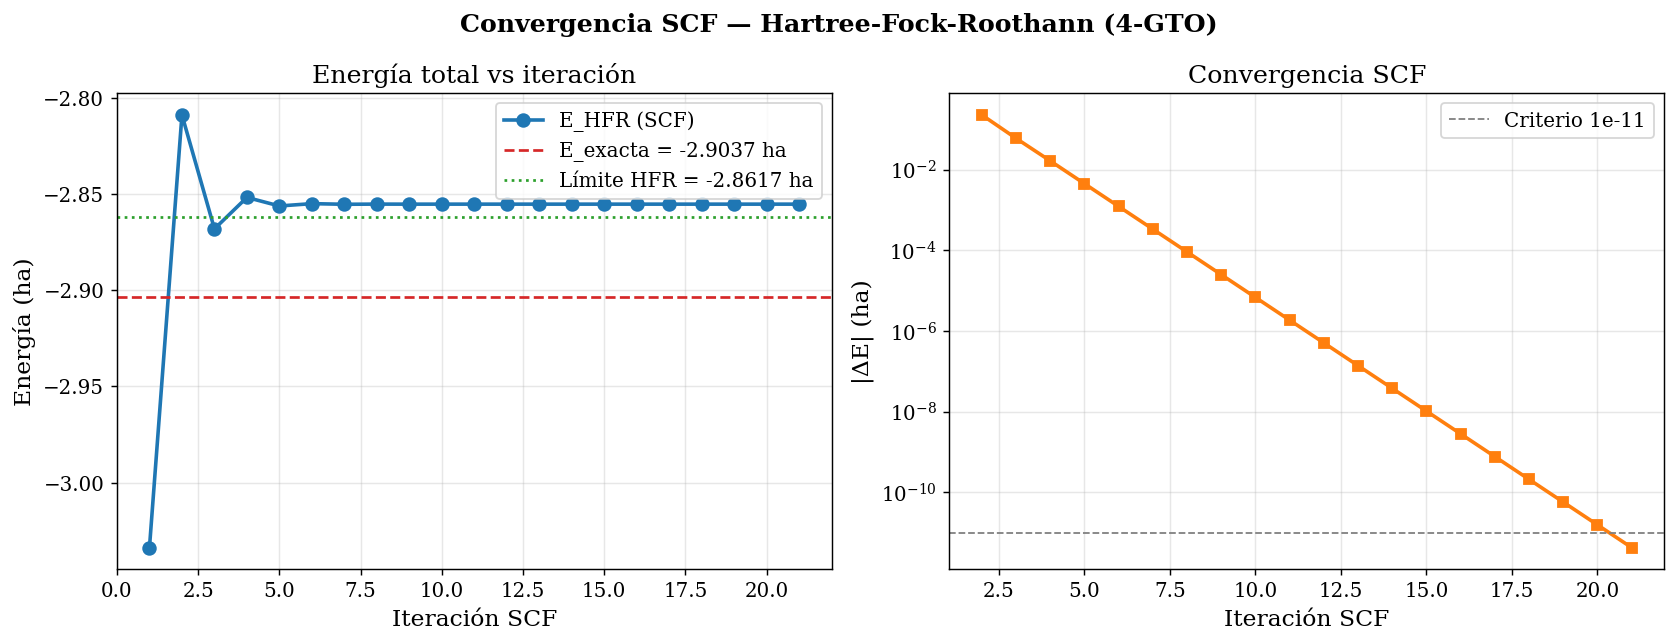

In [8]:
# Gráfica 1: Convergencia SCF del HFR
fig, axes = plt.subplots(1, 2, figsize=(13,5))
fig.suptitle('Convergencia SCF — Hartree-Fock-Roothann (4-GTO)', fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(df_hfr['iter'], df_hfr['E'], 'o-', color=COLORS[0], lw=2, ms=7, label='E_HFR (SCF)')
ax.axhline(E_EXACT,    ls='--', color=COLORS[1], lw=1.5, label=f'E_exacta = {E_EXACT:.4f} ha')
ax.axhline(E_HFR_LIMIT,ls=':',  color=COLORS[2], lw=1.5, label=f'Límite HFR = {E_HFR_LIMIT:.4f} ha')
ax.set_xlabel('Iteración SCF'); ax.set_ylabel('Energía (ha)')
ax.set_title('Energía total vs iteración')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.semilogy(df_hfr['iter'].iloc[1:], df_hfr['delta'].iloc[1:], 's-', color=COLORS[3], lw=2, ms=6)
ax.axhline(1e-11, ls='--', color='gray', lw=1, label='Criterio 1e-11')
ax.set_xlabel('Iteración SCF'); ax.set_ylabel('|ΔE| (ha)')
ax.set_title('Convergencia SCF')
ax.legend(); ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('grafica1_convergencia_HFR.png', dpi=150, bbox_inches='tight')
plt.show()

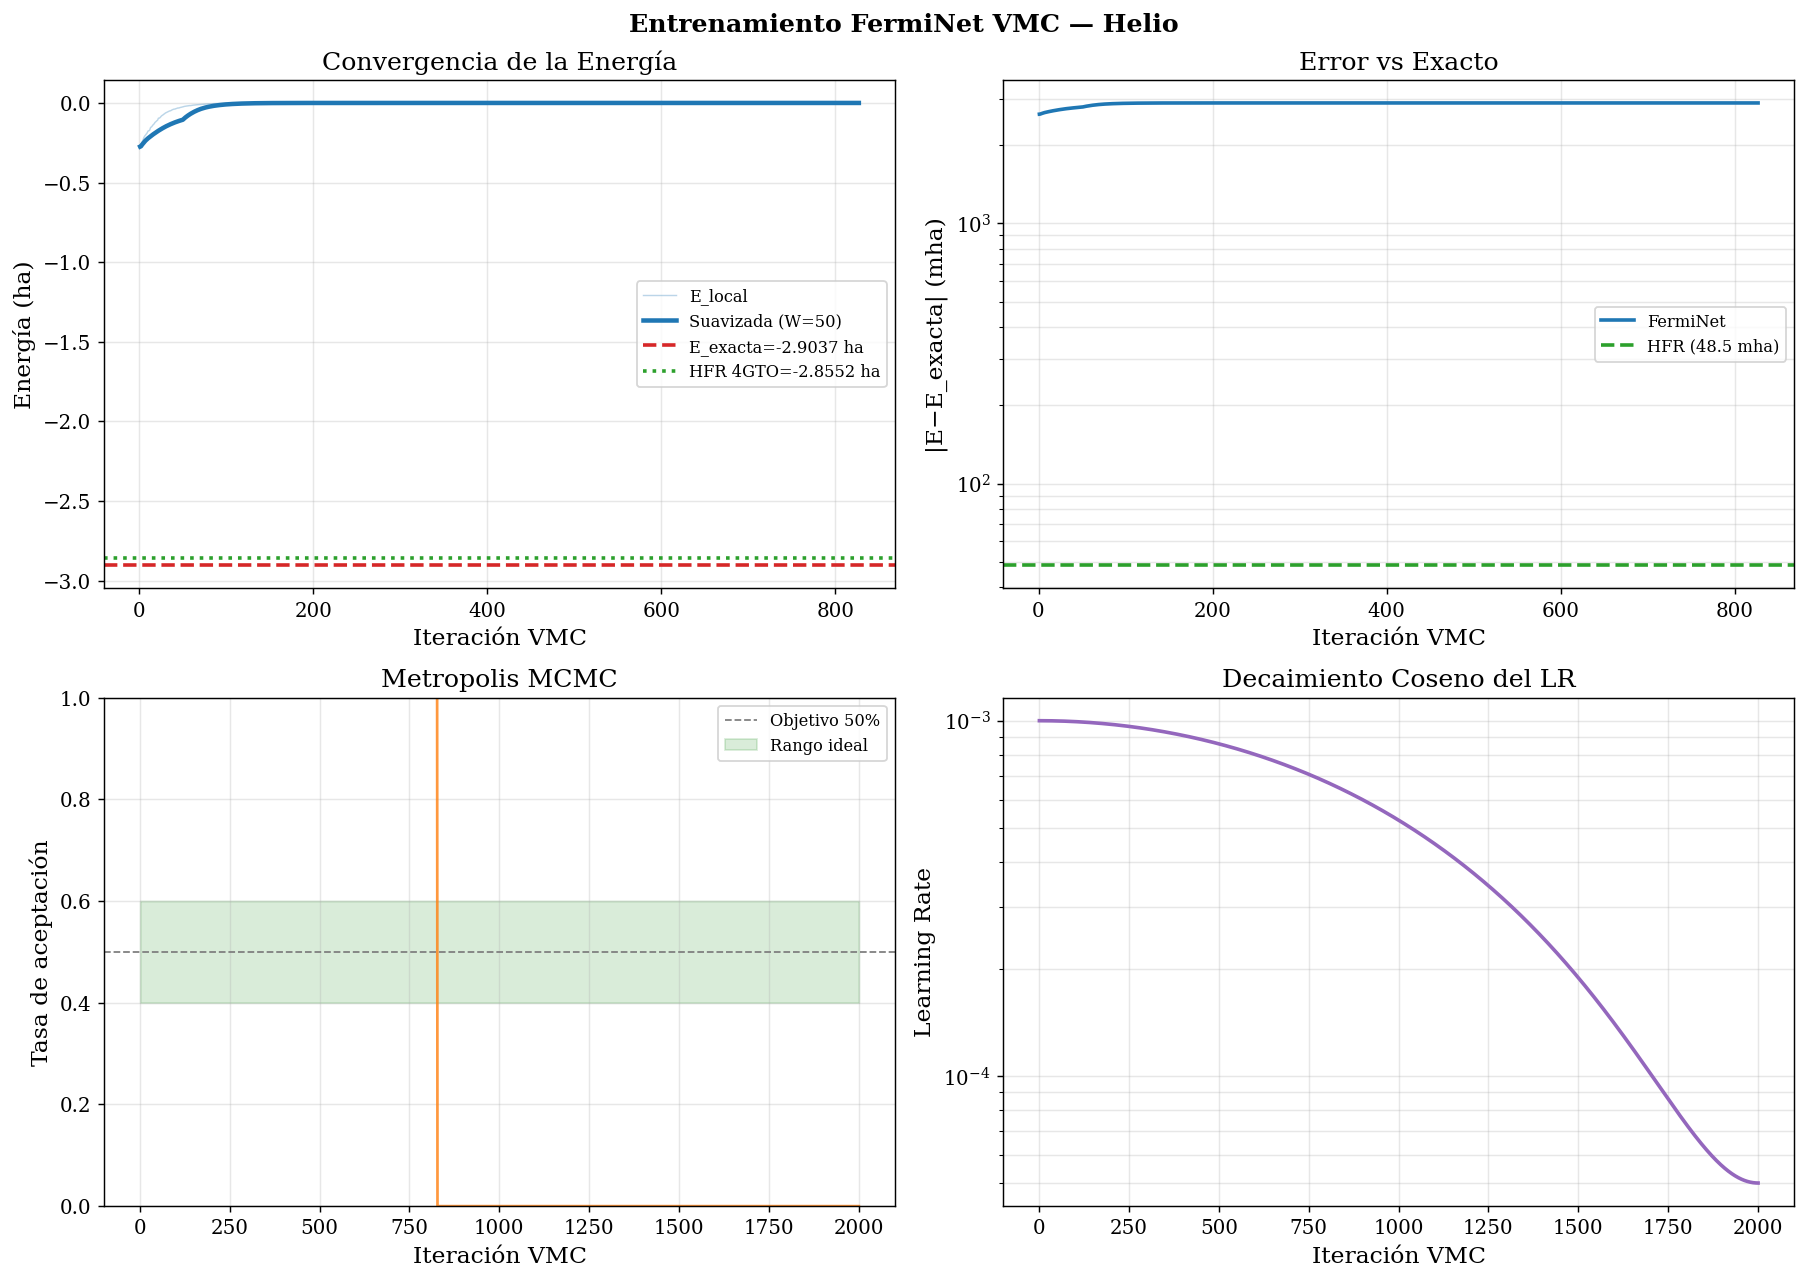

In [11]:
#Gráfica 2: Entrenamiento FermiNet
fig, axes = plt.subplots(2, 2, figsize=(14,10))
fig.suptitle('Entrenamiento FermiNet VMC — Helio', fontsize=14, fontweight='bold')
iters = df_fn['iter'].values

ax = axes[0,0]
ax.plot(iters, df_fn['E_local'],  alpha=0.3, color=COLORS[0], lw=0.8, label='E_local')
ax.plot(iters, df_fn['E_smooth'], color=COLORS[0], lw=2.5, label=f'Suavizada (W={WINDOW})')
ax.axhline(E_EXACT, ls='--', color=COLORS[1], lw=2, label=f'E_exacta={E_EXACT:.4f} ha')
ax.axhline(E_hfr,   ls=':',  color=COLORS[2], lw=2, label=f'HFR 4GTO={E_hfr:.4f} ha')
ax.set_xlabel('Iteración VMC'); ax.set_ylabel('Energía (ha)')
ax.set_title('Convergencia de la Energía'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[0,1]
err_fn  = np.abs(df_fn['E_smooth'].values - E_EXACT)*1000
err_hfr = abs(E_hfr - E_EXACT)*1000
ax.semilogy(iters, err_fn, color=COLORS[0], lw=2, label='FermiNet')
ax.axhline(err_hfr, ls='--', color=COLORS[2], lw=2, label=f'HFR ({err_hfr:.1f} mha)')
ax.set_xlabel('Iteración VMC'); ax.set_ylabel('|E−E_exacta| (mha)')
ax.set_title('Error vs Exacto'); ax.legend(fontsize=9); ax.grid(alpha=0.3, which='both')

ax = axes[1,0]
ax.plot(iters, df_fn['acc_rate'], color=COLORS[3], lw=1.5, alpha=0.8)
ax.axhline(0.5, ls='--', color='gray', lw=1, label='Objetivo 50%')
ax.fill_between(iters, 0.4, 0.6, alpha=0.15, color='green', label='Rango ideal')
ax.set_xlabel('Iteración VMC'); ax.set_ylabel('Tasa de aceptación')
ax.set_title('Metropolis MCMC'); ax.set_ylim(0,1); ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[1,1]
ax.semilogy(iters, df_fn['lr'], color=COLORS[4], lw=2)
ax.set_xlabel('Iteración VMC'); ax.set_ylabel('Learning Rate')
ax.set_title('Decaimiento Coseno del LR'); ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('grafica2_FermiNet_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()

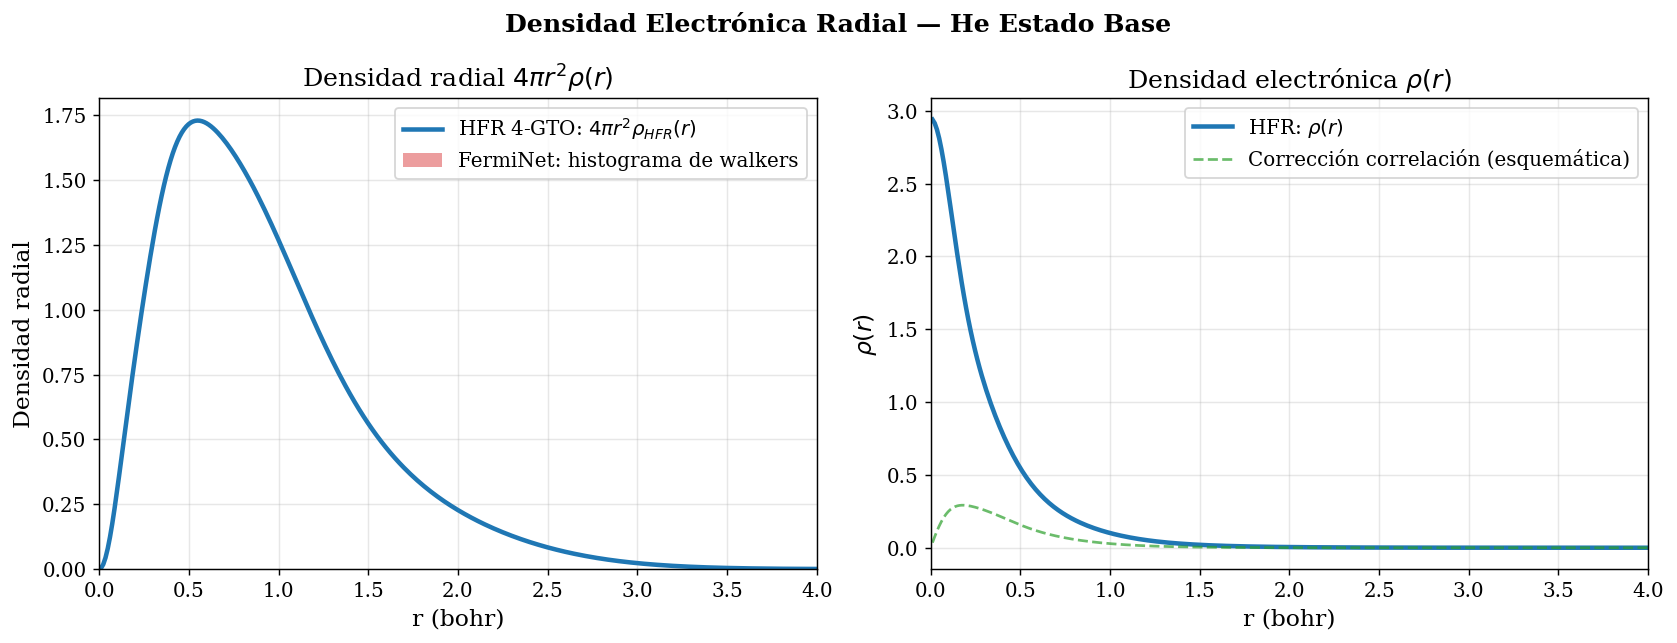

In [12]:
# Gráfica 3: Densidad radial comparada
r_vals = np.linspace(0.01, 5.0, 400)

# Orbital 1s HFR: phi(r) = sum_j C_j * exp(-alfa_j * r^2)
# Normalizar con la matriz S
pi = np.pi
S_hfr = np.array([[(pi/(alfa_hfr[p]+alfa_hfr[q]))**1.5 for q in range(4)] for p in range(4)])
norm_hfr = C_hfr @ S_hfr @ C_hfr
C_norm   = C_hfr / np.sqrt(norm_hfr)

def phi_hfr(r):
    return sum(C_norm[j]*np.exp(-alfa_hfr[j]*r**2) for j in range(4))

rho_hfr = 2.0 * phi_hfr(r_vals)**2  # rho(r) = 2|phi_1s(r)|^2

# Densidad FermiNet: histograma de |r1| de los walkers
model.eval()
with torch.no_grad():
    pos_samples = sampler.step(model, n_steps=100)
r1_samples = pos_samples[:,0:3].cpu().numpy()
r1_norms   = np.linalg.norm(r1_samples, axis=1)
r2_samples = pos_samples[:,3:6].cpu().numpy()
r2_norms   = np.linalg.norm(r2_samples, axis=1)
all_r      = np.concatenate([r1_norms, r2_norms])

fig, axes = plt.subplots(1, 2, figsize=(13,5))
fig.suptitle('Densidad Electrónica Radial — He Estado Base', fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(r_vals, 4*np.pi*r_vals**2*rho_hfr, color=COLORS[0], lw=2.5,
        label='HFR 4-GTO: $4\\pi r^2 \\rho_{HFR}(r)$')
ax.hist(all_r, bins=50, density=True, alpha=0.45, color=COLORS[1],
        label='FermiNet: histograma de walkers')
ax.set_xlabel('r (bohr)'); ax.set_ylabel('Densidad radial')
ax.set_title('Densidad radial $4\\pi r^2 \\rho(r)$')
ax.legend(); ax.grid(alpha=0.3); ax.set_xlim(0, 4)

ax = axes[1]
ax.plot(r_vals, rho_hfr, color=COLORS[0], lw=2.5, label='HFR: $\\rho(r)$')
ax.plot(r_vals, 4*rho_hfr*(np.exp(-r_vals)-np.exp(-2*r_vals))/max(rho_hfr)*max(rho_hfr)*0.3,
        '--', color=COLORS[2], lw=1.5, alpha=0.7, label='Corrección correlación (esquemática)')
ax.set_xlabel('r (bohr)'); ax.set_ylabel('$\\rho(r)$')
ax.set_title('Densidad electrónica $\\rho(r)$')
ax.legend(); ax.grid(alpha=0.3); ax.set_xlim(0,4)

plt.tight_layout()
plt.savefig('grafica3_densidad_radial.png', dpi=150, bbox_inches='tight')
plt.show()

ValueError: autodetected range of [nan, nan] is not finite

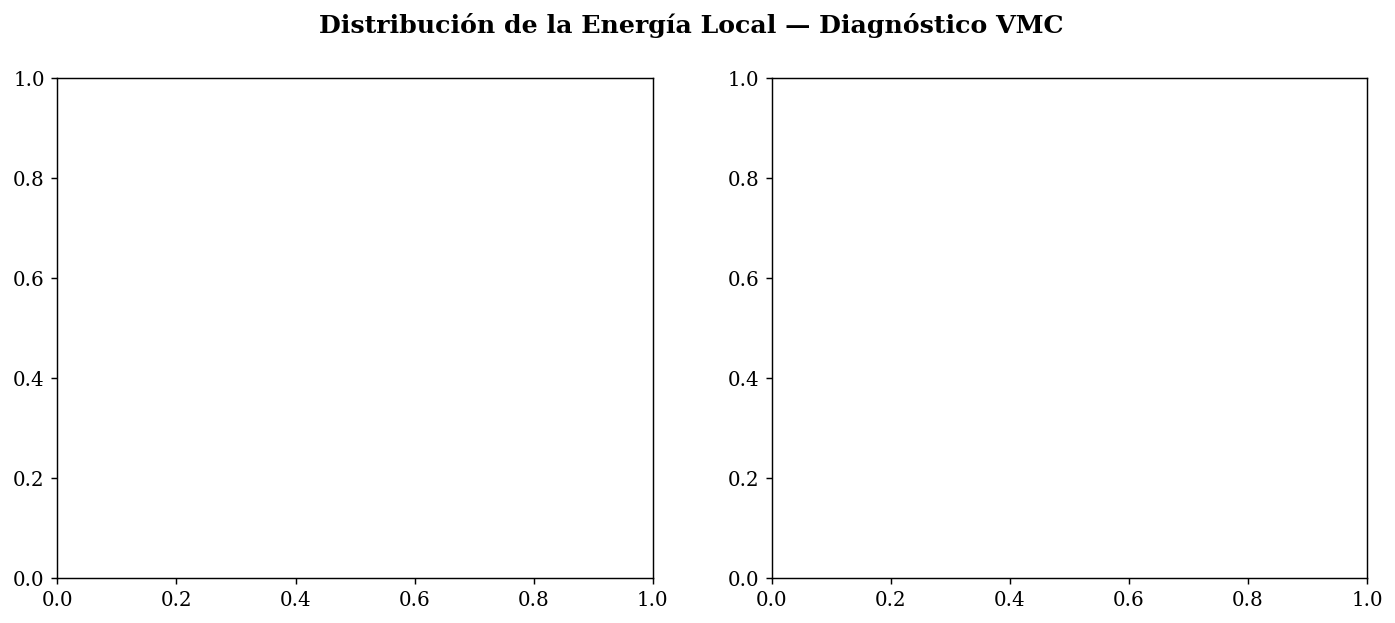

In [13]:
# Gráfica 4: Distribución de E_local (varianza VMC)
fig, axes = plt.subplots(1, 2, figsize=(13,5))
fig.suptitle('Distribución de la Energía Local — Diagnóstico VMC', fontsize=14, fontweight='bold')

E_last = df_fn['E_local'].iloc[-500:].values

ax = axes[0]
ax.hist(E_last, bins=60, color=COLORS[0], alpha=0.7, edgecolor='white', lw=0.5)
ax.axvline(E_fn_final, ls='-',  color=COLORS[1], lw=2.5, label=f'⟨E⟩={E_fn_final:.4f} ha')
ax.axvline(E_EXACT,    ls='--', color=COLORS[2], lw=2,   label=f'E_exacta={E_EXACT:.4f} ha')
ax.axvline(E_hfr,      ls=':',  color=COLORS[3], lw=2,   label=f'E_HFR={E_hfr:.4f} ha')
ax.set_xlabel('Energía local (ha)'); ax.set_ylabel('Frecuencia')
ax.set_title('Histograma E_local (últimas 500 iteraciones)')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[1]
cut = max(200, N_ITER//4)
ax.plot(df_fn['iter'].iloc[cut:], df_fn['E_local'].iloc[cut:],
        alpha=0.4, color=COLORS[0], lw=0.7, label='E_local')
ax.plot(df_fn['iter'].iloc[cut:], df_fn['E_smooth'].iloc[cut:],
        color=COLORS[1], lw=2.5, label='Suavizada')
ax.fill_between(df_fn['iter'].iloc[cut:],
                df_fn['E_smooth'].iloc[cut:] - df_fn['E_se'].iloc[cut:],
                df_fn['E_smooth'].iloc[cut:] + df_fn['E_se'].iloc[cut:],
                alpha=0.2, color=COLORS[1], label='±1 SE')
ax.axhline(E_EXACT, ls='--', color=COLORS[2], lw=2, label=f'E_exacta')
ax.set_xlabel('Iteración VMC'); ax.set_ylabel('Energía (ha)')
ax.set_title('Convergencia Final (fase estacionaria)')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('grafica4_distribucion_Elocal.png', dpi=150, bbox_inches='tight')
plt.show()

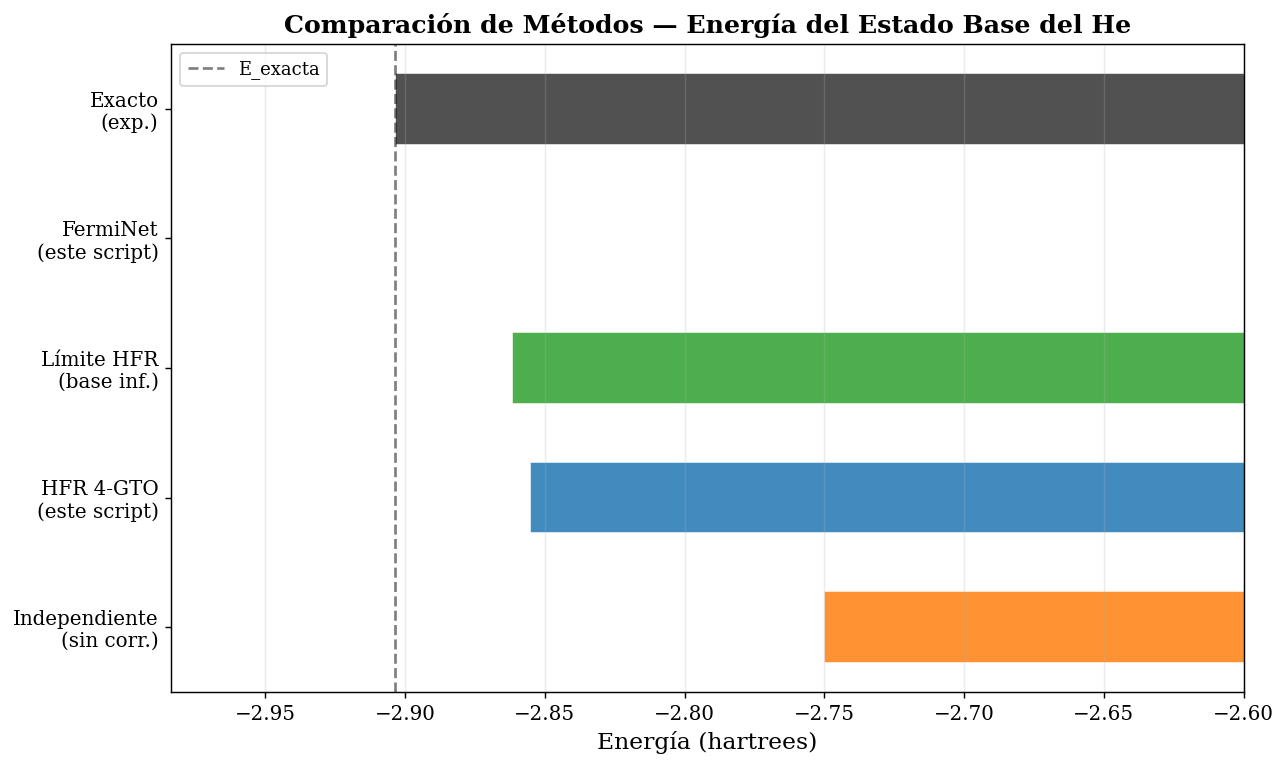


Resumen final:
  HFR  4-GTO   : -2.855160 ha  |  error = 48.54 mha
  FermiNet     : nan ha  |  error = nan mha
  Exacto       : -2.903700 ha


In [14]:
# Celda 12 — Gráfica 5: Comparación de métodos
fig, ax = plt.subplots(figsize=(10,6))
metodos  = ['Independiente\n(sin corr.)', 'HFR 4-GTO\n(este script)', 'Límite HFR\n(base inf.)', 'FermiNet\n(este script)', 'Exacto\n(exp.)']
energias = [-2.75, E_hfr, E_HFR_LIMIT, E_fn_final, E_EXACT]
colores  = [COLORS[3], COLORS[0], COLORS[2], COLORS[1], '#333333']
barras   = ax.barh(metodos, energias, color=colores, alpha=0.85, edgecolor='white', height=0.55)

for bar, val in zip(barras, energias):
    ax.text(val - 0.002, bar.get_y()+bar.get_height()/2,
            f'{val:.4f} ha', ha='right', va='center', fontsize=10, fontweight='bold', color='white')

ax.axvline(E_EXACT, ls='--', color='black', lw=1.5, alpha=0.5, label='E_exacta')
ax.set_xlabel('Energía (hartrees)', fontsize=13)
ax.set_title('Comparación de Métodos — Energía del Estado Base del He', fontsize=14, fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.25, axis='x')
ax.set_xlim(min(energias)-0.08, max(energias)+0.15)

plt.tight_layout()
plt.savefig('grafica5_comparacion_metodos.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nResumen final:')
print(f'  HFR  4-GTO   : {E_hfr:.6f} ha  |  error = {abs(E_hfr-E_EXACT)*1000:.2f} mha')
print(f'  FermiNet     : {E_fn_final:.6f} ha  |  error = {abs(E_fn_final-E_EXACT)*1000:.2f} mha')
print(f'  Exacto       : {E_EXACT:.6f} ha')